In [1]:
from google.colab import files
uploaded = files.upload()

Saving logins_sinteticos_v3_analizador_localizacion_login.csv to logins_sinteticos_v3_analizador_localizacion_login.csv


In [2]:
import pandas as pd

df = pd.read_csv("logins_sinteticos_v3_analizador_localizacion_login.csv")
print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (585, 24)


,user_id,timestamp,ip,known_location,declared_city,declared_region,declared_country,timezone_offset,user_agent,device_type,...,hosting_flag,ip_reputation,is_new_device,country_change,distance_from_prev_km,time_since_prev_min,travel_speed_kmh,timezone_mismatch,scenario_type,expected_result
0,u001,2026-05-02 09:40:00,181.50.10.44,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Chrome Windows,desktop,...,0,low,0,0,0.0,0.0,0.0,0,habitual,bajo
1,u001,2026-05-02 14:17:00,181.50.10.88,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Chrome Windows,desktop,...,0,low,0,0,0.0,277.0,0.0,0,habitual,bajo
2,u001,2026-05-03 19:30:00,181.50.10.64,Bogota,Medellin,Antioquia,Colombia,-05:00,Chrome Windows,desktop,...,0,low,0,0,238.6,1753.0,8.2,0,legit_unusual,medio
3,u001,2026-05-03 20:34:00,181.50.10.210,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Chrome Windows,desktop,...,0,low,0,0,238.6,64.0,223.7,0,habitual,bajo
4,u001,2026-05-04 18:32:00,181.50.10.33,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Chrome Windows,desktop,...,0,low,0,0,0.0,1318.0,0.0,0,habitual,bajo


In [6]:
import pandas as pd
from analizador_localizacion_login_v3 import load_dataset, run_analysis, build_summary_tables, CONFIG

df = load_dataset("logins_sinteticos_v3_analizador_localizacion_login.csv")
df_results = run_analysis(df, CONFIG)

summary_risk, summary_comparison, summary_by_scenario = build_summary_tables(df_results)

print("Eventos procesados:", len(df_results))
display(df_results.head(10))
display(summary_risk)
display(summary_comparison)
display(summary_by_scenario)

Eventos procesados: 585


,user_id,timestamp,ip,known_location,declared_city,declared_region,declared_country,timezone_offset,user_agent,device_type,...,distance_from_prev_km,time_since_prev_min,travel_speed_kmh,timezone_mismatch,scenario_type,expected_result,risk_score,risk_level,risk_reasons,comparison_result
0,u001,2026-05-02 09:40:00,181.50.10.44,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Chrome Windows,desktop,...,0.0,0.0,0.0,0,habitual,bajo,0,bajo,,acierto
1,u001,2026-05-02 14:17:00,181.50.10.88,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Chrome Windows,desktop,...,0.0,277.0,0.0,0,habitual,bajo,0,bajo,,acierto
2,u001,2026-05-03 19:30:00,181.50.10.64,Bogota,Medellin,Antioquia,Colombia,-05:00,Chrome Windows,desktop,...,238.6,1753.0,8.2,0,legit_unusual,medio,20,bajo,localizacion_distinta_a_la_habitual,subestimacion
3,u001,2026-05-03 20:34:00,181.50.10.210,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Chrome Windows,desktop,...,238.6,64.0,223.7,0,habitual,bajo,0,bajo,,acierto
4,u001,2026-05-04 18:32:00,181.50.10.33,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Chrome Windows,desktop,...,0.0,1318.0,0.0,0,habitual,bajo,0,bajo,,acierto
5,u001,2026-05-04 20:09:00,181.50.10.165,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Chrome Windows,desktop,...,0.0,97.0,0.0,0,habitual,bajo,0,bajo,,acierto
6,u001,2026-05-05 14:22:00,181.50.10.66,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Chrome Windows,desktop,...,0.0,-357.0,0.0,0,habitual,bajo,0,bajo,,acierto
7,u001,2026-05-05 20:19:00,181.50.10.29,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Chrome Windows,desktop,...,0.0,1450.0,0.0,0,habitual,bajo,0,bajo,,acierto
8,u001,2026-05-06 14:49:00,181.50.10.183,Bogota,Bogota,Cundinamarca,Colombia,-05:00,Chrome Windows,desktop,...,0.0,1467.0,0.0,0,habitual,bajo,0,bajo,,acierto
9,u001,2026-05-06 15:09:00,45.155.205.16,Bogota,Moscow,Moscow,Russia,+03:00,Tor Browser,desktop,...,10898.4,20.0,32695.2,1,suspicious,alto,94,alto,localizacion_distinta_a_la_habitual; cambio_de...,acierto


,risk_level,count
0,bajo,476
1,alto,55
2,medio,54


,comparison_result,count
0,acierto,501
1,sobrestimacion,45
2,subestimacion,39


risk_level,scenario_type,alto,bajo,medio
0,ambiguous,1,30,8
1,habitual,0,437,21
2,legit_unusual,23,9,25
3,suspicious,31,0,0


In [7]:
df_results.to_csv("resultados_v3_analizador_localizacion_login.csv", index=False)
summary_risk.to_csv("resumen_riesgo_v3.csv", index=False)
summary_comparison.to_csv("resumen_comparacion_v3.csv", index=False)
summary_by_scenario.to_csv("resumen_escenario_vs_riesgo_v3.csv", index=False)

print("Archivos guardados correctamente.")

Archivos guardados correctamente.


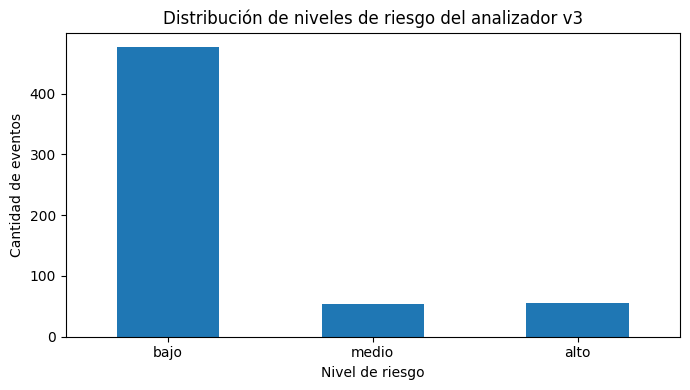

In [8]:
import matplotlib.pyplot as plt

conteo = df_results["risk_level"].value_counts().reindex(["bajo", "medio", "alto"])

plt.figure(figsize=(7,4))
conteo.plot(kind="bar")
plt.title("Distribución de niveles de riesgo del analizador v3")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad de eventos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

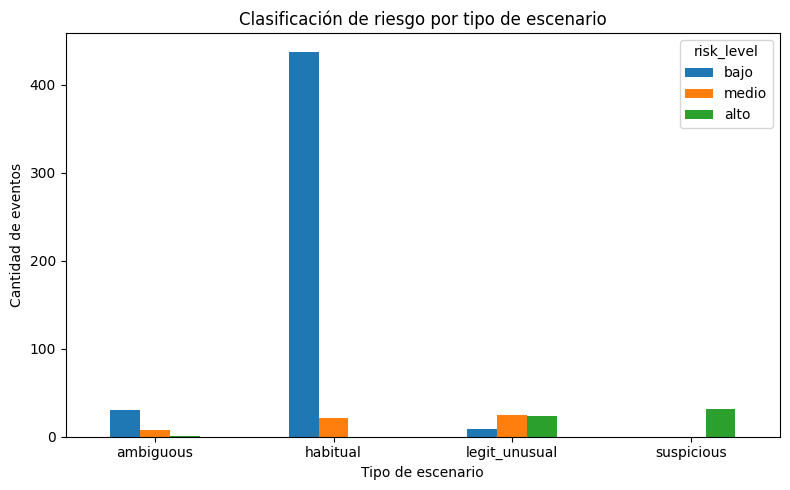

In [9]:
tabla_plot = pd.crosstab(df_results["scenario_type"], df_results["risk_level"])
tabla_plot = tabla_plot.reindex(columns=["bajo", "medio", "alto"])

tabla_plot.plot(kind="bar", figsize=(8,5))
plt.title("Clasificación de riesgo por tipo de escenario")
plt.xlabel("Tipo de escenario")
plt.ylabel("Cantidad de eventos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

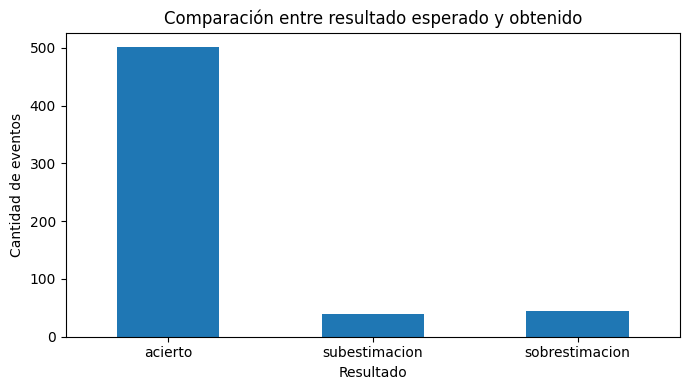

In [10]:
comparacion_plot = df_results["comparison_result"].value_counts().reindex(
    ["acierto", "subestimacion", "sobrestimacion"]
)

plt.figure(figsize=(7,4))
comparacion_plot.plot(kind="bar")
plt.title("Comparación entre resultado esperado y obtenido")
plt.xlabel("Resultado")
plt.ylabel("Cantidad de eventos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Resultado obtenido  bajo  medio  alto
Resultado esperado                   
bajo                 437     21     0
medio                 39     33    24
alto                   0      0    31


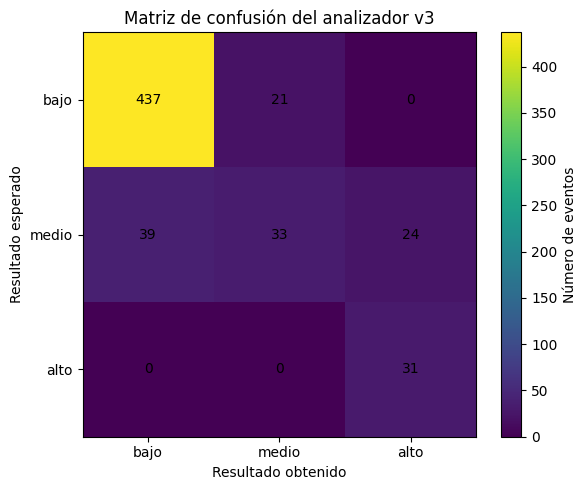

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Matriz de confusión
conf_matrix = pd.crosstab(
    df_results["expected_result"],
    df_results["risk_level"],
    rownames=["Resultado esperado"],
    colnames=["Resultado obtenido"]
).reindex(index=["bajo", "medio", "alto"], columns=["bajo", "medio", "alto"], fill_value=0)

print(conf_matrix)

plt.figure(figsize=(6,5))
plt.imshow(conf_matrix, aspect="auto")
plt.title("Matriz de confusión del analizador v3")
plt.xlabel("Resultado obtenido")
plt.ylabel("Resultado esperado")
plt.xticks(range(len(conf_matrix.columns)), conf_matrix.columns)
plt.yticks(range(len(conf_matrix.index)), conf_matrix.index)

for i in range(len(conf_matrix.index)):
    for j in range(len(conf_matrix.columns)):
        plt.text(j, i, conf_matrix.iloc[i, j], ha="center", va="center")

plt.colorbar(label="Número de eventos")
plt.tight_layout()
plt.show()

risk_level     bajo  medio  alto
scenario_type                   
habitual        437     21     0
legit_unusual     9     25    23
ambiguous        30      8     1
suspicious        0      0    31


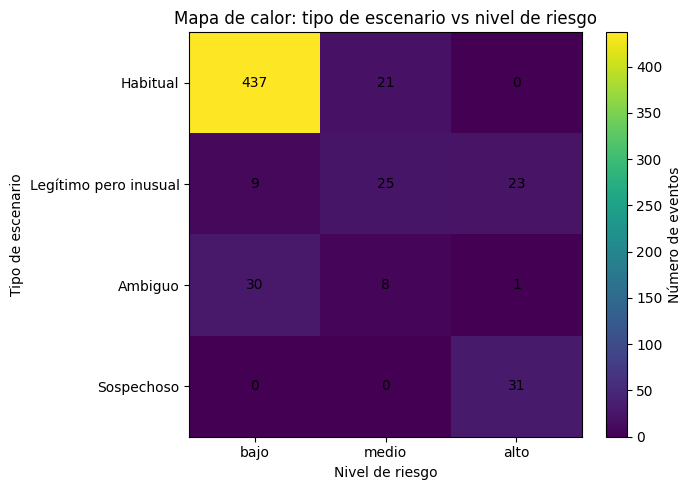

In [12]:
tabla_heatmap = pd.crosstab(df_results["scenario_type"], df_results["risk_level"])
tabla_heatmap = tabla_heatmap.reindex(
    index=["habitual", "legit_unusual", "ambiguous", "suspicious"],
    columns=["bajo", "medio", "alto"],
    fill_value=0
)

print(tabla_heatmap)

plt.figure(figsize=(7,5))
plt.imshow(tabla_heatmap, aspect="auto")
plt.title("Mapa de calor: tipo de escenario vs nivel de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Tipo de escenario")
plt.xticks(range(len(tabla_heatmap.columns)), tabla_heatmap.columns)
plt.yticks(range(len(tabla_heatmap.index)), ["Habitual", "Legítimo pero inusual", "Ambiguo", "Sospechoso"])

for i in range(len(tabla_heatmap.index)):
    for j in range(len(tabla_heatmap.columns)):
        plt.text(j, i, tabla_heatmap.iloc[i, j], ha="center", va="center")

plt.colorbar(label="Número de eventos")
plt.tight_layout()
plt.show()

In [13]:
total_eventos = len(df_results)
aciertos = (df_results["comparison_result"] == "acierto").sum()
subestimaciones = (df_results["comparison_result"] == "subestimacion").sum()
sobrestimaciones = (df_results["comparison_result"] == "sobrestimacion").sum()
accuracy = aciertos / total_eventos

tabla_resumen = pd.DataFrame({
    "Métrica": [
        "Número total de eventos",
        "Eventos clasificados en riesgo bajo",
        "Eventos clasificados en riesgo medio",
        "Eventos clasificados en riesgo alto",
        "Aciertos",
        "Subestimaciones",
        "Sobrestimaciones",
        "Accuracy global"
    ],
    "Valor": [
        total_eventos,
        (df_results["risk_level"] == "bajo").sum(),
        (df_results["risk_level"] == "medio").sum(),
        (df_results["risk_level"] == "alto").sum(),
        aciertos,
        subestimaciones,
        sobrestimaciones,
        f"{accuracy:.2%}"
    ]
})

display(tabla_resumen)

,Métrica,Valor
0,Número total de eventos,585
1,Eventos clasificados en riesgo bajo,476
2,Eventos clasificados en riesgo medio,54
3,Eventos clasificados en riesgo alto,55
4,Aciertos,501
5,Subestimaciones,39
6,Sobrestimaciones,45
7,Accuracy global,85.64%
